In [ ]:
%pip install puremacro


# Identificación de choques estructurales: SVAR

Un VAR en forma reducida captura la dinámica pero no la estructura *causal*.
Aquí plantamos un choque monetario contractivo conocido en un VAR(2) sintético
y lo recuperamos de dos formas — identificación recursiva por **Cholesky** y
**restricciones de signo** — usando `puremacro.var.identify`. Todo se ejecuta
en el navegador con datos sintéticos.

## De la forma reducida a la estructura

Un VAR($p$) en forma reducida proyecta cada variable sobre el pasado reciente de todas las variables:
$$ y_t = A_1 y_{t-1} + \cdots + A_p y_{t-p} + u_t, \qquad \mathbb{E}[u_t u_t'] = \Sigma_u. $$
Los residuos $u_t$ son *errores de pronóstico*, no choques económicos — están correlacionados entre
ecuaciones ($\Sigma_u$ no es diagonal). Los choques estructurales $\varepsilon_t$ son las
perturbaciones económicas mutuamente no correlacionadas, relacionadas con los residuos mediante
una matriz de impacto $B$:
$$ u_t = B\,\varepsilon_t,\qquad \mathbb{E}[\varepsilon_t\varepsilon_t']=I \;\Rightarrow\; \Sigma_u = BB'. $$

**El problema de identificación.** $\Sigma_u$ es simétrica, por lo que determina únicamente $n(n+1)/2$
parámetros, pero $B$ tiene $n^2$ elementos libres. Faltan $n(n-1)/2$ restricciones — para $n=3$,
tres de ellas. *Cómo* se suministran esas restricciones define el esquema de identificación:

- **Cholesky** establece $B=\operatorname{chol}(\Sigma_u)$, el factor triangular inferior único.
  Sus $n(n-1)/2$ ceros sobre la diagonal *son* las restricciones: un ordenamiento recursivo en el
  que la variable 1 no reacciona a ningún choque en el impacto, la variable 2 solo al choque 1, y así sucesivamente.
- **Restricciones de signo** utilizan que para *cualquier* matriz ortogonal $Q$ ($QQ'=I$), $\tilde B = BQ$
  también satisface $\Sigma_u = \tilde B\tilde B'$. En lugar de ceros, se retienen todas las rotaciones
  cuyas respuestas de impacto coinciden con una prior de signos. Muchas $B$ son admisibles, por lo que
  el choque está **identificado en conjunto** — se reporta la mediana y una banda sobre las rotaciones admisibles.

**Intuición.** Un ordenamiento recursivo es un supuesto *económico* sobre qué puede moverse dentro del
período; reordenar las variables cambia el "choque". Las restricciones de signo asumen menos, por lo que
identifican un *conjunto* de respuestas — de ahí que sus bandas sean más amplias.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.identify.cholesky import cholesky_svar
from puremacro.var.identify.sign import sign_restriction_svar

## 1. Un VAR(2) monetario sintético con un choque plantado
Simulamos un VAR(2) estable en `[output, prices, rate]`. La matriz de impacto
estructural `B0_true` planta un choque de política monetaria contractivo como su
primera columna: en el impacto empuja **la producción hacia abajo, los precios
hacia abajo y la tasa de política hacia arriba**. Intentaremos recuperar
exactamente este choque de dos maneras distintas.

In [2]:
A1 = np.array([
    [0.6, 0.0, -0.1],
    [0.2, 0.5,  0.0],
    [0.0, 0.1,  0.7],
])
A2 = np.array([
    [0.1, 0.0, 0.0],
    [0.0, 0.2, 0.0],
    [0.0, 0.0, 0.1],
])
B0_true = np.array([
    [-0.5,  0.6,  0.0],   # output
    [-0.4,  0.0,  0.3],   # prices
    [ 0.4,  0.0,  0.5],   # rate
])
names = ["output", "prices", "rate"]
RATE = 2   # index of the policy variable

def simulate(T=400, seed=0, burn=200):
    rng = np.random.default_rng(seed)
    n = B0_true.shape[0]
    eps = rng.standard_normal((T + burn, n))
    Y = np.zeros((T + burn, n))
    for t in range(2, T + burn):
        Y[t] = A1 @ Y[t - 1] + A2 @ Y[t - 2] + B0_true @ eps[t]
    return Y[burn:]

Y = simulate(T=400, seed=0)
planted_signs = np.sign(B0_true[:, 0])
print("planted monetary-shock signs (output, prices, rate):", planted_signs)
assert tuple(planted_signs) == (-1.0, -1.0, +1.0)

planted monetary-shock signs (output, prices, rate): [-1. -1.  1.]


## 2. Identificación por Cholesky (ordenamiento recursivo)
Con el ordenamiento `[output, prices, rate]`, la tasa de política puede
reaccionar a la producción y a los precios *dentro del período* pero no al
revés, de modo que el choque monetario recursivo es la **última** ecuación.
Las bandas de confianza provienen de un bootstrap de residuos.

In [3]:
H = 16
chol = cholesky_svar(Y, p=2, horizon=H, n_boot=400, ci=0.9, seed=0)
print(chol.summary())
CHOL_SHOCK = RATE
c_point = chol.irf_point[:, :, CHOL_SHOCK]   # (H+1, n)
c_lower = chol.irf_lower[:, :, CHOL_SHOCK]
c_upper = chol.irf_upper[:, :, CHOL_SHOCK]
print(f"Cholesky impact, rate -> rate shock = {c_point[0, RATE]:+.3f}")
assert c_point[0, RATE] > 0                       # policy rate jumps up on impact
assert np.all(c_lower <= c_point + 1e-9)          # lower <= point everywhere
assert np.all(c_point <= c_upper + 1e-9)          # point <= upper everywhere

Cholesky SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  bootstrap draws   : 400 (dropped 0, 0.0%)

Cholesky impact, rate -> rate shock = +0.584


## 3. Identificación por restricciones de signo (Rubio-Ramirez-Waggoner-Zha)
Imponemos únicamente los *signos* de la respuesta de impacto: en `h=0` el
choque monetario hace que la producción y los precios sean negativos y que la
tasa sea positiva. Cada rotación de Haar admisible que satisface la prior se
retiene; la tendencia central es la **mediana** entre los sorteos (no una
estimación puntual única).

In [4]:
restrictions = {0: [-1, -1, +1]}                  # h=0: output-, prices-, rate+
sgn = sign_restriction_svar(
    Y, p=2, horizon=H, restrictions=restrictions,
    n_draws=600, ci=0.9, seed=0,
)
print(sgn.summary())
TARGET = 0                                         # target shock = column 0 after rotation
s_med = sgn.irf_median[:, :, TARGET]              # (H+1, n)
s_lower = sgn.irf_lower[:, :, TARGET]
s_upper = sgn.irf_upper[:, :, TARGET]
print("sign-restriction impact (output, prices, rate):",
      np.round(s_med[0], 3))
# Sign pattern at h=0 matches the planted shock
assert np.sign(s_med[0, 0]) == -1
assert np.sign(s_med[0, 1]) == -1
assert np.sign(s_med[0, 2]) == +1
assert sgn.n_accepted > 0
# Bands bracket the median everywhere
assert np.all(s_lower <= s_med + 1e-9)
assert np.all(s_med <= s_upper + 1e-9)
# Both schemes agree the policy rate rises on impact
assert c_point[0, RATE] > 0 and s_med[0, RATE] > 0

Sign-restriction SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  Q draws           : 600 (119 accepted, 19.8%)

sign-restriction impact (output, prices, rate): [-0.422 -0.285  0.342]


### Figura principal — un choque, dos identificaciones
Normalizar la FIR de la tasa de política de cada esquema a un impacto de `+1`
pone las respuestas recursiva y con restricciones de signo en la misma escala.
Ambas trazan un decaimiento sin joroba, pero la banda con restricciones de
signo es *más amplia* — la identificación de conjunto deja la forma sólo
parcialmente determinada.

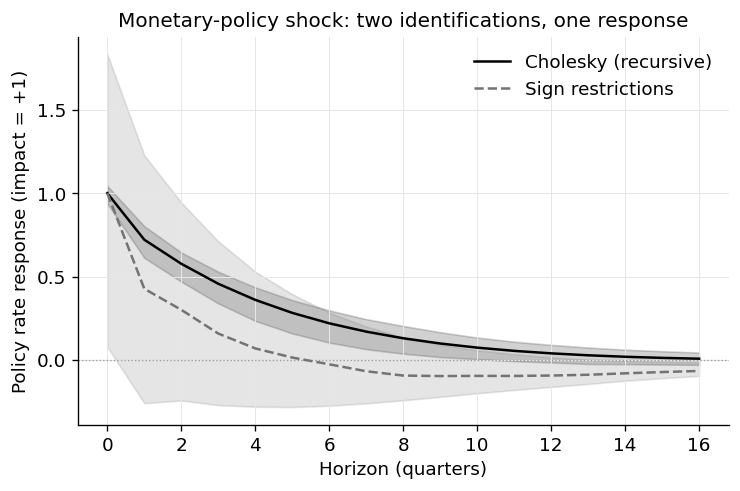

In [5]:
hgrid = np.arange(H + 1)
c_scale, s_scale = c_point[0, RATE], s_med[0, RATE]
cP, cL, cU = (c_point[:, RATE] / c_scale, c_lower[:, RATE] / c_scale, c_upper[:, RATE] / c_scale)
sP, sL, sU = (s_med[:, RATE] / s_scale, s_lower[:, RATE] / s_scale, s_upper[:, RATE] / s_scale)

cols = _nbstyle.palette(2)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, cL, cU, color=cols[0], alpha=0.18)
ax.plot(hgrid, cP, color=cols[0], label="Cholesky (recursive)")
ax.fill_between(hgrid, sL, sU, color=cols[1], alpha=0.18)
ax.plot(hgrid, sP, color=cols[1], linestyle="--", label="Sign restrictions")
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Policy rate response (impact = +1)")
ax.set_title("Monetary-policy shock: two identifications, one response")
ax.legend(loc="upper right")
plt.show()

### Apoyo — patrón de signos en el impacto (h=0)
En el impacto, ambos esquemas reproducen los signos plantados: producción a la
baja, precios a la baja y tasa al alza.

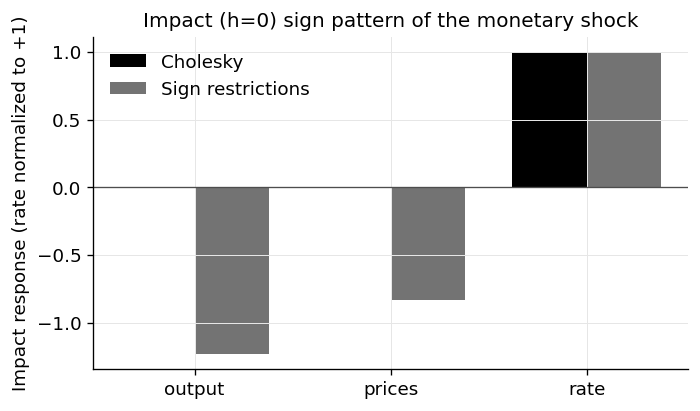

In [6]:
x, w = np.arange(3), 0.38
chol_impact = chol.irf_point[0, :, CHOL_SHOCK] / c_scale
sign_impact = sgn.irf_median[0, :, TARGET] / s_scale
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.bar(x - w / 2, chol_impact, w, color=cols[0], label="Cholesky")
ax.bar(x + w / 2, sign_impact, w, color=cols[1], label="Sign restrictions")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("Impact response (rate normalized to +1)")
ax.set_title("Impact (h=0) sign pattern of the monetary shock")
ax.legend()
plt.show()

### Apoyo — FIR de todas las variables (restricciones de signo)
El conjunto de respuestas con identificación parcial de cada variable al choque
monetario, con bandas al 90% tomadas sobre las rotaciones admisibles.

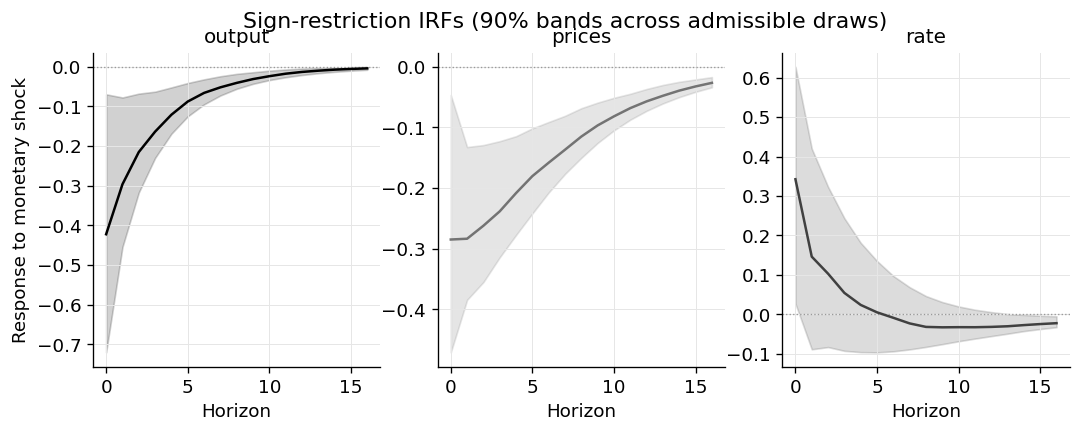

In [7]:
c3 = _nbstyle.palette(3)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), sharex=True)
for i, (axk, nm) in enumerate(zip(axes, names)):
    axk.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
    axk.fill_between(hgrid, sgn.irf_lower[:, i, TARGET], sgn.irf_upper[:, i, TARGET],
                     color=c3[i], alpha=0.18)
    axk.plot(hgrid, sgn.irf_median[:, i, TARGET], color=c3[i])
    axk.set_title(nm); axk.set_xlabel("Horizon")
axes[0].set_ylabel("Response to monetary shock")
fig.suptitle("Sign-restriction IRFs (90% bands across admissible draws)")
plt.show()

## Tu turno — el orden es un supuesto

El choque recursivo de un SVAR de Cholesky depende del orden de las variables: la respuesta
contemporánea de una variable *anterior* al choque de una variable *posterior* es cero por
construcción. Reordena las columnas de `Y` y observa cómo una respuesta de impacto que era
cero se vuelve distinta de cero. Cambia `order` a continuación.

In [8]:
# ← Change this ordering (a permutation of 0=output, 1=prices, 2=rate).
order = [2, 0, 1]                      # rate FIRST → output/prices may now react on impact
Y_re = Y[:, order]
chol_re = cholesky_svar(Y_re, p=2, horizon=H, n_boot=200, ci=0.9, seed=0)
pos = {v: order.index(v) for v in (0, 1, 2)}            # new position of each original var
# Output's contemporaneous response to the rate shock:
out_to_rate = chol_re.irf_point[0, pos[0], pos[RATE]]
print(f"order={order}: output's impact response to the rate shock = {out_to_rate:+.3f}")
# With the rate ordered before output, this is no longer forced to zero (it was, originally).
assert abs(out_to_rate) > 1e-8

order=[2, 0, 1]: output's impact response to the rate shock = -0.282


**Ejercicios.** (1) Cambia la prior de signos en `restrictions` (por ejemplo, a
`{0: [-1, -1, -1]}`) y vuelve a ejecutar la celda de restricciones de signo — ¿cómo cambian
el número de rotaciones aceptadas (`sgn.n_accepted`) y la banda identificada? (Con solo tres
restricciones de impacto la prior sigue siendo satisfacible, así que el conjunto se desplaza
en vez de desaparecer.) (2) Pon la tasa *al final*
(`order=[0, 1, 2]`) y confirma que `out_to_rate` regresa a ≈0 (el cero recursivo original).
(3) Amplía el bootstrap (`n_boot=800`) y comprueba cuánto se mueve la FIR puntual.

**¿Qué tan completa es la biblioteca?** `puremacro.var` / `puremacro.svar` van mucho más
allá de estos dos esquemas: restricciones de largo plazo de Blanchard-Quah, proxy-SVAR /
identificación por instrumentos externos (p. ej., choques fiscales narrativos de
Mertens-Ravn), descomposiciones de varianza del error de pronóstico y descomposiciones
históricas. La galería `examples/` (`bloom2009`, `sign_restrictions_uhlig`,
`svariv_mertens_ravn`, `gk_robust_signs`) ejecuta cada caso de principio a fin.